# Chronos-2 — Group Topology & Attention Inspection

`group_ids` govern cross-series attention in the Chronos-2 encoder:

| Strategy | Meaning |
|---|---|
| **Isolated** (`cross_learning=False`) | every series gets a unique id — no cross-series attention |
| **Fully shared** (`cross_learning=True`) | all series share id 0 — full batch cross-attention |
| **Custom topology** (`compute_group_ids`) | repo-defined clusters — partial sharing |

This notebook loads a multi-series FEV dataset, runs all three strategies, then compares forecasts and the resulting group attention matrices side-by-side.

## 1. Install dependencies

In [1]:
# Run once, then restart the kernel
%pip install -q chronos-forecasting pandas torch matplotlib datasets pyarrow ipywidgets


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import sys
from pathlib import Path

# Walk up from cwd until we find the repo root (the folder containing chronos_custom/)
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "chronos_custom").exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        print(f"Repo root added to sys.path: {_candidate}")
        break
else:
    raise RuntimeError("chronos_custom/ not found — run this notebook from inside the repo.")

Repo root added to sys.path: /Users/ruoccoma/Documents/Playground/chronos-custom


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from chronos import Chronos2Pipeline

from chronos_custom import (
    CustomChronosPipeline,
    compute_group_ids,
    load_fev_long_dataframe,
    infer_fev_target_columns,
)

# Quick sanity check — default rule for 9 series should produce 3-per-group clusters
print("compute_group_ids(9) →", compute_group_ids(9).tolist())

compute_group_ids(9) → [0, 0, 0, 0, 0, 1, 1, 1, 1]


## 3. Settings

Adjust the widgets, then **re-run this cell** to propagate the values to all downstream cells.

In [12]:
import ipywidgets as widgets
from IPython.display import display as _display

# ── widget definitions (persistent across re-runs of this cell) ──────────────
if "w_n_series" not in dir():
    w_model = widgets.Dropdown(
        options=["amazon/chronos-2"],
        value="amazon/chronos-2",
        description="Model:",
        style={"description_width": "120px"},
        layout=widgets.Layout(width="380px"),
    )
    w_fev_config = widgets.Dropdown(
        options=[
            # ETT datasets
            "ETT_15T", "ETT_1D", "ETT_1H", "ETT_1W",
            # LOOP Seattle
            "LOOP_SEATTLE_1D", "LOOP_SEATTLE_1H", "LOOP_SEATTLE_5T",
            # M_DENSE
            "M_DENSE_1D", "M_DENSE_1H",
            # SZ_TAXI
            "SZ_TAXI_15T", "SZ_TAXI_1H",
            # Tourism and other economic data
            "australian_tourism",
            # BizIT observations
            "bizitobs_l2c_1H", "bizitobs_l2c_5T",
            # BOOM datasets (boomlet)
            "boomlet_1062", "boomlet_1209", "boomlet_1225", "boomlet_1230", "boomlet_1282",
            "boomlet_1487", "boomlet_1631", "boomlet_1676", "boomlet_1855", "boomlet_1975",
            "boomlet_2187", "boomlet_285", "boomlet_619", "boomlet_772", "boomlet_963",
            # ECDC (disease surveillance)
            "ecdc_ili",
            # ENTSOE (power systems)
            "entsoe_15T", "entsoe_1H", "entsoe_30T",
            # EPF (electricity price forecasting)
            "epf_be", "epf_de", "epf_fr", "epf_np", "epf_pjm",
            # ERCOT (energy)
            "ercot_1D", "ercot_1H", "ercot_1M", "ercot_1W",
            # Favorita (retail sales)
            "favorita_stores_1D", "favorita_stores_1M", "favorita_stores_1W",
            "favorita_transactions_1D", "favorita_transactions_1M", "favorita_transactions_1W",
            # FRED (macroeconomic)
            "fred_md_2025", "fred_qd_2025",
            # GVAR (global economic)
            "gvar",
            # HERMES (traffic/transport)
            "hermes",
            # Hierarchical sales
            "hierarchical_sales_1D", "hierarchical_sales_1W",
            # Hospital admissions
            "hospital_admissions_1D", "hospital_admissions_1W", "hospital",
            # Jena weather
            "jena_weather_10T", "jena_weather_1D", "jena_weather_1H",
            # KDD Cup 2022
            "kdd_cup_2022_10T", "kdd_cup_2022_1D", "kdd_cup_2022_30T",
            # M5 (retail)
            "m5_1D", "m5_1M", "m5_1W",
            # ProEnFo (renewable energy forecasting)
            "proenfo_bull", "proenfo_cockatoo", "proenfo_gfc12", "proenfo_gfc14",
            "proenfo_gfc17", "proenfo_hog", "proenfo_pdb",
            # REDSET (electrical systems)
            "redset_15T", "redset_1H", "redset_5T",
            # Restaurant visitor forecasting
            "restaurant",
            # Rohlik (e-commerce orders/sales)
            "rohlik_orders_1D", "rohlik_orders_1W",
            "rohlik_sales_1D", "rohlik_sales_1W",
            # Rossmann (retail)
            "rossmann_1D", "rossmann_1W",
            # Solar
            "solar_1D", "solar_1W",
            "solar_with_weather_15T", "solar_with_weather_1H",
            # UCI Air Quality
            "uci_air_quality_1D", "uci_air_quality_1H",
            # UK COVID data
            "uk_covid_nation_1D", "uk_covid_nation_1W",
            "uk_covid_utla_1D", "uk_covid_utla_1W",
            # US Consumption
            "us_consumption_1M", "us_consumption_1Q", "us_consumption_1Y",
            # Walmart (retail)
            "walmart",
            # World data
            "world_co2_emissions", "world_life_expectancy", "world_tourism",
        ],
        value="LOOP_SEATTLE_1H",
        description="FEV config:",
        style={"description_width": "120px"},
        layout=widgets.Layout(width="380px"),
    )
    w_n_series = widgets.IntSlider(
        value=9, min=2, max=500, step=1,
        description="N_SERIES:",
        continuous_update=False,
        style={"description_width": "120px"},
        layout=widgets.Layout(width="380px"),
    )
    w_pred_len = widgets.IntSlider(
        value=24, min=6, max=168, step=6,
        description="Pred length:",
        continuous_update=False,
        style={"description_width": "120px"},
        layout=widgets.Layout(width="380px"),
    )
    w_plot_idx = widgets.IntSlider(
        value=0, min=0, max=49, step=1,
        description="Plot series idx:",
        continuous_update=False,
        style={"description_width": "120px"},
        layout=widgets.Layout(width="380px"),
    )

    def _clamp_plot_idx(change):
        w_plot_idx.max = w_n_series.value - 1
        w_plot_idx.value = min(w_plot_idx.value, w_n_series.value - 1)

    w_n_series.observe(_clamp_plot_idx, names="value")

_display(widgets.VBox([
    w_model, w_fev_config, w_n_series, w_pred_len, w_plot_idx,
]))

# ── read current widget values into module-level variables ───────────────────
MODEL_ID          = w_model.value
FEV_CONFIG        = w_fev_config.value
FEV_SPLIT         = "train"
N_SERIES          = w_n_series.value
PREDICTION_LENGTH = w_pred_len.value
PLOT_SERIES_IDX   = w_plot_idx.value

print(f"Model           : {MODEL_ID}")
print(f"FEV config      : {FEV_CONFIG}")
print(f"N_SERIES        : {N_SERIES}")
print(f"Prediction len  : {PREDICTION_LENGTH}")
print(f"Plot series idx : {PLOT_SERIES_IDX}")


Model           : amazon/chronos-2
FEV config      : LOOP_SEATTLE_1H
N_SERIES        : 30
Prediction len  : 36
Plot series idx : 29


## 4. Load FEV data

We use the repo's `load_fev_long_dataframe` helper to pull a traffic speed dataset from Hugging Face.  
The result is a long dataframe with columns `id`, `timestamp`, `target`.

In [13]:
context_df, value_columns = load_fev_long_dataframe(
    FEV_CONFIG,
    split=FEV_SPLIT,
    max_series=N_SERIES,
)
target_col = infer_fev_target_columns(value_columns)[0]
series_ids = context_df["id"].unique().tolist()

print(f"DataFrame shape : {context_df.shape}")
print(f"Target column   : {target_col}")
print(f"Series ids      : {series_ids}")
context_df.head()

DataFrame shape : (262800, 3)
Target column   : target
Series ids      : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '30']


,id,timestamp,target
0,0,2015-01-01 00:00:00,62.189457
1,0,2015-01-01 01:00:00,62.927940
2,0,2015-01-01 02:00:00,63.341717
3,0,2015-01-01 03:00:00,63.144405
4,0,2015-01-01 04:00:00,63.002350


## 5. Group topology strategies

We compare three ways to assign `group_ids` to the `N_SERIES` series in the batch.

,isolated,fully_shared,custom
series_id,,,
0,0,0,0
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0
5,5,0,1
6,6,0,1
7,7,0,1
8,8,0,1


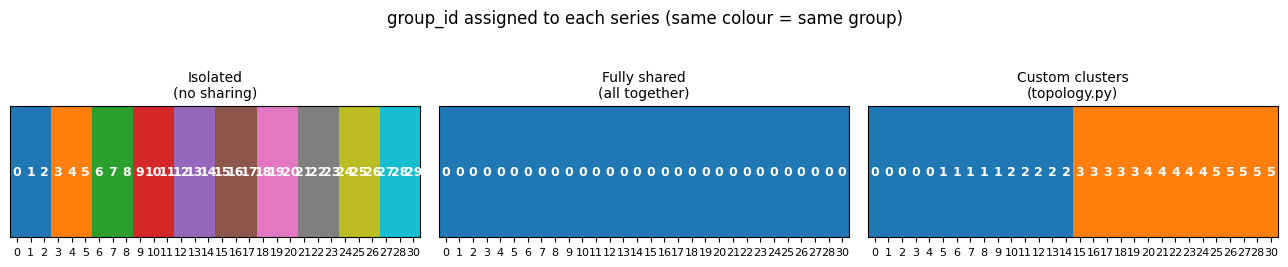

In [14]:
n = len(series_ids)

# Strategy A — isolated: every series is its own group (no cross-series attention)
group_isolated = torch.arange(n)

# Strategy B — fully shared: all series share one group (maximum cross-attention)
group_shared = torch.zeros(n, dtype=torch.long)

# Strategy C — custom clusters: repo default, roughly equal-size groups
group_custom = compute_group_ids(n)

topology_df = pd.DataFrame({
    "series_id"     : series_ids,
    "isolated"      : group_isolated.tolist(),
    "fully_shared"  : group_shared.tolist(),
    "custom"        : group_custom.tolist(),
})

# Pretty-print with colours in output
display(topology_df.set_index("series_id"))

# Visualise the three strategies as a colour grid
fig, axes = plt.subplots(1, 3, figsize=(13, 2.5))
for ax, (col, title, cmap) in zip(axes, [
    ("isolated",     "Isolated\n(no sharing)",       "tab10"),
    ("fully_shared", "Fully shared\n(all together)", "tab10"),
    ("custom",       "Custom clusters\n(topology.py)","tab10"),
]):
    vals = topology_df[col].values.reshape(1, -1)
    ax.imshow(vals, cmap=cmap, vmin=0, vmax=max(n - 1, 1), aspect="auto")
    ax.set_xticks(range(n))
    ax.set_xticklabels([str(s) for s in series_ids], fontsize=8)
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    for i, v in enumerate(topology_df[col].values):
        ax.text(i, 0, str(v), ha="center", va="center", fontsize=9, color="white",
                fontweight="bold")

plt.suptitle("group_id assigned to each series (same colour = same group)", y=1.05)
plt.tight_layout()
plt.show()

## 6. Load model and run all three strategies

In [15]:
custom_pipeline   = CustomChronosPipeline.from_pretrained(MODEL_ID)
original_pipeline = Chronos2Pipeline.from_pretrained(MODEL_ID)
print("Models loaded.")

_common = dict(
    prediction_length=PREDICTION_LENGTH,
    id_column="id",
    timestamp_column="timestamp",
    target=target_col,
)

# --- Isolated (original pipeline, cross_learning=False) ---
pred_isolated = original_pipeline.predict_df(context_df, **_common, cross_learning=False)
print("Isolated forecast done.")

# --- Fully shared (original pipeline, cross_learning=True) ---
pred_shared = original_pipeline.predict_df(context_df, **_common, cross_learning=True)
print("Fully-shared forecast done.")

# --- Custom topology (custom pipeline) ---
custom_pipeline.reset_attentions()
pred_custom = custom_pipeline.predict_df(context_df, **_common)
print("Custom forecast done.")

print("\nAll forecasts ready. Shapes:", pred_isolated.shape, pred_shared.shape, pred_custom.shape)

Models loaded.
Isolated forecast done.
Fully-shared forecast done.
Using group_ids:
tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
        4, 5, 5, 5, 5, 5])
Custom forecast done.

All forecasts ready. Shapes: (1080, 13) (1080, 13) (1080, 13)


## 7. Forecast comparison

Three rows, one per strategy, for a single highlighted series.

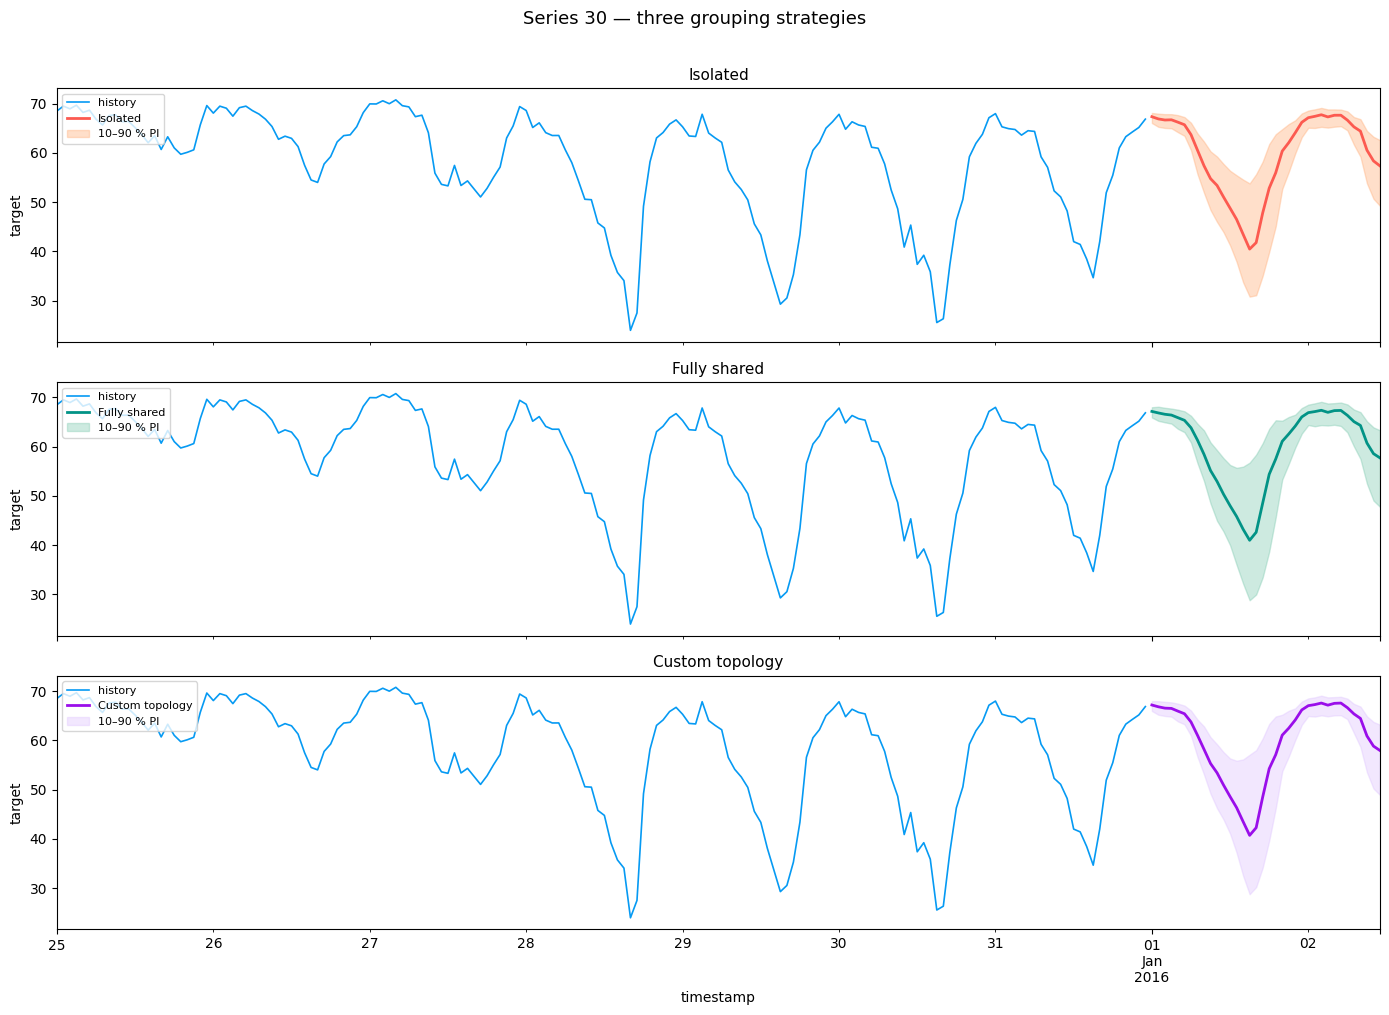

In [16]:
sid = series_ids[PLOT_SERIES_IDX]

ts_hist = (
    context_df[context_df["id"] == sid]
    .sort_values("timestamp")
    .set_index("timestamp")[target_col]
    .tail(168)   # last week of context
)

strategies = [
    (pred_isolated, "Isolated",       "xkcd:coral",        "xkcd:peach"),
    (pred_shared,   "Fully shared",   "xkcd:teal",         "xkcd:pale teal"),
    (pred_custom,   "Custom topology","xkcd:violet",       "xkcd:light lavender"),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (preds, label, fc, fill) in zip(axes, strategies):
    ts_pred = preds[preds["id"] == sid].set_index("timestamp")
    ts_hist.plot(ax=ax, label="history", color="xkcd:azure", linewidth=1.2)
    ts_pred["predictions"].plot(ax=ax, label=label, color=fc, linewidth=2)
    ax.fill_between(
        ts_pred.index, ts_pred["0.1"], ts_pred["0.9"],
        alpha=0.4, color=fill, label="10–90 % PI",
    )
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
    ax.set_ylabel(target_col)

plt.suptitle(f"Series {sid} — three grouping strategies", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Inspect captured attention tensors

`custom_pipeline.time_attentions` — temporal self-attention (tokens within each series)  
`custom_pipeline.group_attentions` — group self-attention (series cross-attention within each group)

Each list has one entry per autoregressive step; each entry is a tuple of tensors, one per encoder layer.

In [17]:
n_steps  = len(custom_pipeline.time_attentions)
n_layers = len(custom_pipeline.time_attentions[0]) if n_steps else 0

print(f"Autoregressive steps captured : {n_steps}")
print(f"Encoder layers                : {n_layers}")
if n_steps and n_layers:
    t_shape = tuple(custom_pipeline.time_attentions[0][0].shape)
    g_shape = tuple(custom_pipeline.group_attentions[0][0].shape)
    print(f"Time-attn  shape (step 0, layer 0): {t_shape}  → (batch, heads, query_tokens, key_tokens)")
    print(f"Group-attn shape (step 0, layer 0): {g_shape}  → (tokens, heads, query_series, key_series)")

Autoregressive steps captured : 1
Encoder layers                : 12
Time-attn  shape (step 0, layer 0): (30, 12, 516, 516)  → (batch, heads, query_tokens, key_tokens)
Group-attn shape (step 0, layer 0): (516, 12, 30, 30)  → (tokens, heads, query_series, key_series)


## 9. Group attention matrix — custom topology

The group attention tensor has shape `(tokens, heads, series, series)`.  
We average over tokens and heads to get a single `(N_SERIES × N_SERIES)` matrix  
showing how strongly each series attends to every other series in the encoder.

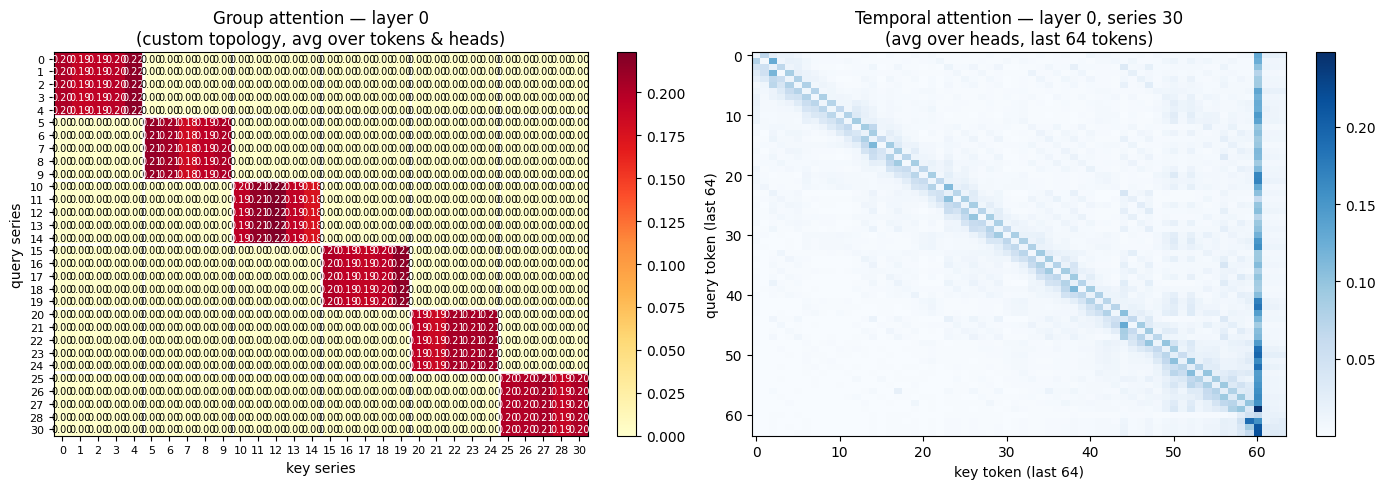

In [18]:
LAYER = 0   # encoder layer to inspect (0–11)

# Group-attn tensor: (tokens, heads, n_series, n_series) → average over tokens and heads
g_tensor = custom_pipeline.group_attentions[0][LAYER]   # shape: (T, H, N, N)
group_mat = g_tensor.mean(dim=(0, 1)).cpu().numpy()     # shape: (N, N)

# Temporal-attn tensor: (n_series, heads, T, T) → pick PLOT_SERIES_IDX, avg over heads
t_tensor  = custom_pipeline.time_attentions[0][LAYER]   # shape: (N, H, T, T)
time_mat  = t_tensor[PLOT_SERIES_IDX].mean(dim=0).cpu().numpy()

sid_labels = [str(s) for s in series_ids]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Group attention heatmap ---
im0 = axes[0].imshow(group_mat, cmap="YlOrRd", aspect="auto")
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(sid_labels, fontsize=8)
axes[0].set_yticks(range(n)); axes[0].set_yticklabels(sid_labels, fontsize=8)
axes[0].set_xlabel("key series"); axes[0].set_ylabel("query series")
axes[0].set_title(f"Group attention — layer {LAYER}\n(custom topology, avg over tokens & heads)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Draw cluster boundaries derived from group_custom
boundaries = []
prev = group_custom[0].item()
for i, g in enumerate(group_custom.tolist()[1:], 1):
    if g != prev:
        boundaries.append(i - 0.5)
        prev = g
for b in boundaries:
    axes[0].axhline(b, color="white", linewidth=2)
    axes[0].axvline(b, color="white", linewidth=2)

# Annotate each cell with the attention value
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, f"{group_mat[i, j]:.2f}",
                     ha="center", va="center", fontsize=7,
                     color="black" if group_mat[i, j] < group_mat.max() * 0.6 else "white")

# --- Temporal attention heatmap (last 64 tokens for readability) ---
T = time_mat.shape[0]
clip = min(64, T)
tm = time_mat[-clip:, -clip:]
im1 = axes[1].imshow(tm, cmap="Blues", aspect="auto")
axes[1].set_xlabel("key token (last 64)"); axes[1].set_ylabel("query token (last 64)")
axes[1].set_title(f"Temporal attention — layer {LAYER}, series {sid}\n(avg over heads, last {clip} tokens)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 10. Next steps

- Edit `compute_group_ids()` in [topology.py](../chronos_custom/topology.py) and re-run from cell 5 to see the effect on attention and forecasts.
- Increase `LAYER` (0–11) in cell 9 to inspect how attention patterns evolve across encoder depth.
- Increase `N_SERIES` (and reduce `PREDICTION_LENGTH`) to stress-test larger topologies.